# Consigna

En este primer trabajo comenzaremos por diseñar un generador de señales que utilizaremos en las primeras simulaciones que hagamos. La primer tarea consistirá en programar una función que genere señales senoidales y que permita parametrizar:

la amplitud máxima de la senoidal (volts)
su valor medio (volts)
la frecuencia (Hz)
la fase (radianes)
la cantidad de muestras digitalizada por el ADC (# muestras)
la frecuencia de muestreo del ADC.
es decir que la función que uds armen debería admitir se llamada de la siguiente manera

tt, xx = mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs)


# Resultado

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    xx = np.array(xx).reshape(nn,1)
    tt = tt.reshape(nn,1)

    return tt, xx

def mi_funcion_cuadrada(vmax = 1, dc = 0, ff = 1, duty = .5, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray] :
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.where(tt % (1/ff) < (1/ff) * duty, 1, -1)
    xx = vmax * xx + dc
    #signal.square(2* np.pi * ff* tt, duty)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return tt, xx

def mi_funcion_triangular(vmax = 1, dc = 0, ff = 1, nn = 1, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop= nn*ts, step=ts)
    T = 1/ff

    xx = [((vmax/T) * (i%T) + dc) for i in tt]
    #signal.sawtooth(2* np.pi * ff* tt, 0.5)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return tt, xx

def noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    '''
        noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
        Genera ruido gaussiano con varianza var.

        Nota: El ruido blanco se define como normal o gaussiano, con media 0 y con una varianza igual a la potencia de ruido
        (Extraido de apuntes de ASYS de procesos estocásticos, "ruido blanco")
    '''
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.random.normal(loc=0, scale=var, size=nn)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return tt, xx

def mi_sen_ruidosa( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000, snr = 20) -> tuple[np.ndarray,np.ndarray]:
    tt, xx = mi_funcion_sen(vmax, dc, ff, ph, nn, fs)
    var_noise = ((vmax**2)/2) / (10**(snr/10))  # Calculando potencia de señal conocida "senoidal"
    # var_noise = power(xx) / (10**(snr/10))    # Lo mismo, calculando potencia por definicion
    
    _, noise = noise_generator(var_noise, nn, fs)
    xx = xx + noise

    return tt, xx

def power(x: np.ndarray) -> float:
    return np.mean(x**2)

def snr(signal: np.ndarray, noise: np.ndarray) -> float:
    return 10 * np.log10(np.mean(signal**2) / np.mean(noise**2))


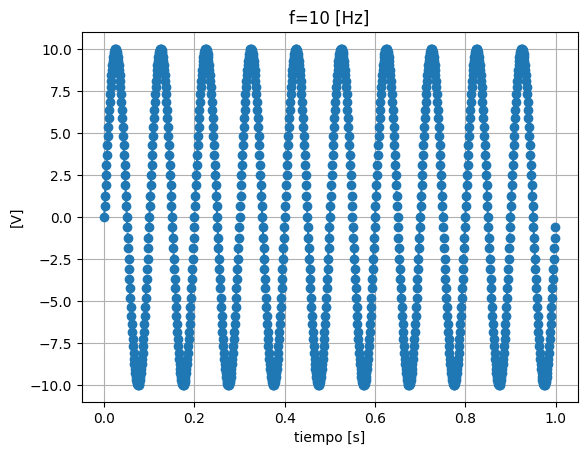

In [ ]:
# Varaibles ############################################################
N = 1000
fs = 1000      #Hz
duty = .85
ff = 10

# Funciones ############################################################
tt, x1 = mi_funcion_triangular( vmax = 1, dc = 0, ff = ff, nn = N, fs = fs)
tt, x2 = mi_funcion_sen( vmax = 10, dc = 0, ff = ff, nn = N, ph = 0, fs = fs)
tt, x3 = mi_funcion_cuadrada( vmax = 1, dc = 0, ff = ff, duty = duty, nn = N, fs = fs)


# Grafico ############################################################
plt.title(f'f={ff} [Hz]')
plt.xlabel('tiempo [s]')
plt.ylabel('[V]')

#plt.plot(tt, x1,'x--')
plt.plot(tt, x2,'o--')
#plt.plot(tt, x3,'*--')

plt.grid()
plt.show()


# Nota de los gráficos:
1. La frecuencia de Nyquist es Fmax/2. En este caso es 500. El primer gráfico se encuentra a dicha frecuencia, por lo que la gráfica debería ser 0. Se obverva algo parecido a ruido pero con valores menores el femto, por lo que puede considerarse error del propio redondeo de un float o de python.
2. La señal es mucho más rápida que la frecuencia de Nyquist. Se observa el efecto de aliasing. Si se analizaran deltas en el espectro, al muestrearlas se cortaría al espectro en Fs y se repetiría infinitamente. El resultado es de 1HZ porque se encuentra a 1Hz por debajo de la fs (obteniendose la delta negativa de la senoidal)
3. Mismo efecto que en 2. pero ahora con la delta positiva, puesto que estamos por encima.
4. Mismo efecto que en 3.

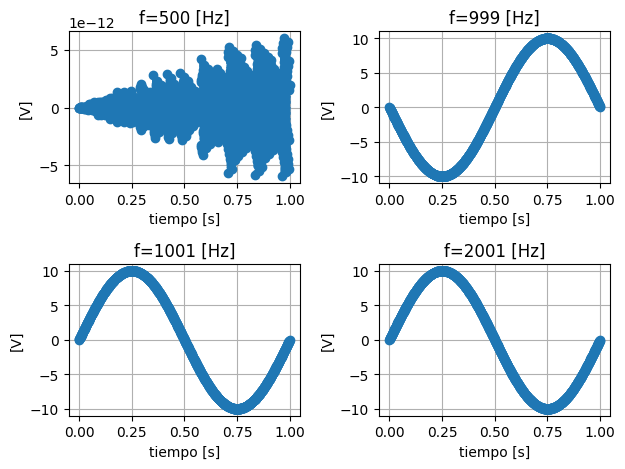

In [5]:
# Varaibles ############################################################
N = 1000
fs = 1000      #Hz

# Funciones ############################################################
tt, x1 = mi_funcion_sen( vmax = 10, dc = 0, ff = 500, nn = N, fs = fs)
_, x2 = mi_funcion_sen( vmax = 10, dc = 0, ff = 999, nn = N, fs = fs)
_, x3 = mi_funcion_sen( vmax = 10, dc = 0, ff = 1001, nn = N, fs = fs)
_, x4 = mi_funcion_sen( vmax = 10, dc = 0, ff = 2001, nn = N, fs = fs)


# Grafico ############################################################
plt.subplot(2,2,1)
plt.title(f'f=500 [Hz]')
plt.xlabel('tiempo [s]')
plt.ylabel('[V]')
plt.plot(tt, x1,'o--')
plt.grid()

plt.subplot(2,2,2)
plt.title(f'f=999 [Hz]')
plt.xlabel('tiempo [s]')
plt.ylabel('[V]')
plt.plot(tt, x2,'o--')
plt.grid()

plt.subplot(2,2,3)
plt.title(f'f=1001 [Hz]')
plt.xlabel('tiempo [s]')
plt.ylabel('[V]')
plt.plot(tt, x3,'o--')
plt.grid()

plt.subplot(2,2,4)
plt.title(f'f=2001 [Hz]')
plt.xlabel('tiempo [s]')
plt.ylabel('[V]')
plt.plot(tt, x4,'o--')
plt.grid()

plt.tight_layout()
plt.show()

# Señal senoidal Ruidosa

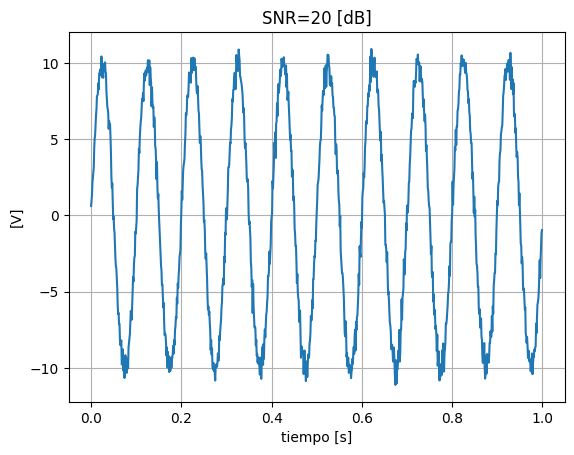

In [6]:
## Var
fs = 1000
N = 1000

vmax = 10
f = 10
snr = 20

tt, xx = mi_sen_ruidosa(vmax=vmax, ff=f, nn=N, fs=fs, snr=snr)

plt.title(f'SNR={snr} [dB]')
plt.xlabel('tiempo [s]')
plt.ylabel('[V]')
plt.plot(tt, xx)
plt.grid()
